In [20]:
#polarity, id, date, query, user, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# for better plots in notebook
%matplotlib inline

# (Optional) set a style for seaborn
sns.set(style='whitegrid')

# Paths to your CSV files
train_path = 'sentiment140/training.1600000.processed.noemoticon.csv'  # update with your actual path
test_path = 'sentiment140/testdata.manual.2009.06.14.csv'

# Read the training data
train_df = pd.read_csv(train_path, 
                       encoding='ISO-8859-1',  # Sent140 is often in this encoding
                       header=None)

# Read the test data
test_df = pd.read_csv(test_path, 
                      encoding='ISO-8859-1',  
                      header=None)

In [3]:
train_df.columns = ['polarity', 'id', 'date', 'query', 'user', 'text']
test_df.columns  = ['polarity', 'id', 'date', 'query', 'user', 'text']


In [4]:
# Dimensions
print("Training Set Shape:", train_df.shape)
print("Test Set Shape:", test_df.shape)

# Column names
print("\nColumns:", train_df.columns.tolist())

# Head (first few rows)
print("\nSample Training Rows:")
display(train_df.head(5))

print("\nSample Test Rows:")
display(test_df.head(5))


Training Set Shape: (1600000, 6)
Test Set Shape: (498, 6)

Columns: ['polarity', 'id', 'date', 'query', 'user', 'text']

Sample Training Rows:


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."



Sample Test Rows:


,polarity,id,date,query,user,text
0,4,3,Mon May 11 03:17:40 UTC 2009,kindle2,tpryan,@stellargirl I loooooooovvvvvveee my Kindle2. ...
1,4,4,Mon May 11 03:18:03 UTC 2009,kindle2,vcu451,Reading my kindle2... Love it... Lee childs i...
2,4,5,Mon May 11 03:18:54 UTC 2009,kindle2,chadfu,"Ok, first assesment of the #kindle2 ...it fuck..."
3,4,6,Mon May 11 03:19:04 UTC 2009,kindle2,SIX15,@kenburbary You'll love your Kindle2. I've had...
4,4,7,Mon May 11 03:21:41 UTC 2009,kindle2,yamarama,@mikefish Fair enough. But i have the Kindle2...


Training Polarity Counts:
 polarity
0    800000
4    800000
Name: count, dtype: int64

Test Polarity Counts:
 polarity
4    182
0    177
2    139
Name: count, dtype: int64


/tmp/ipykernel_673672/3305943032.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_counts.index,
/tmp/ipykernel_673672/3305943032.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=test_counts.index,


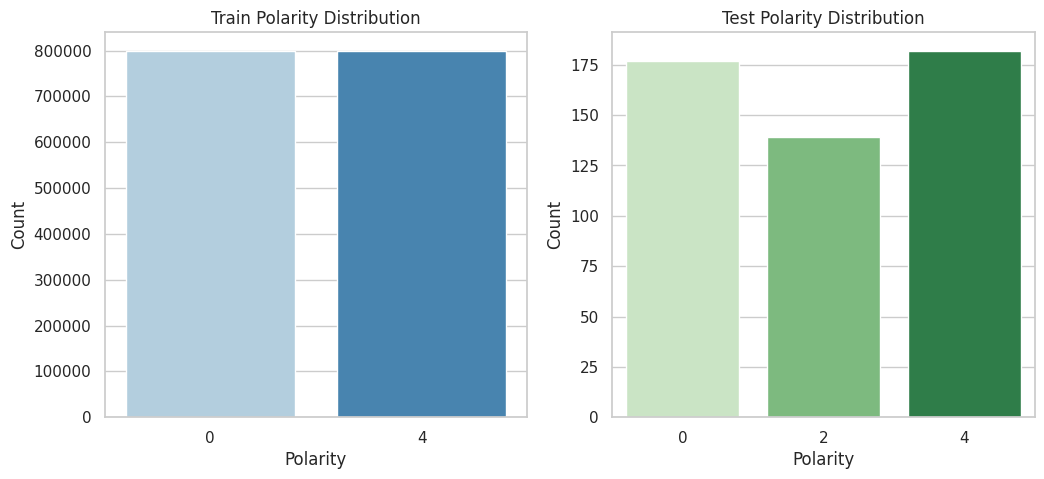

In [5]:
# Polarity distribution in train
train_counts = train_df['polarity'].value_counts()
print("Training Polarity Counts:\n", train_counts)

# Polarity distribution in test
test_counts = test_df['polarity'].value_counts()
print("\nTest Polarity Counts:\n", test_counts)

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=train_counts.index, 
            y=train_counts.values, 
            ax=axes[0], 
            palette='Blues')
axes[0].set_title("Train Polarity Distribution")
axes[0].set_xlabel("Polarity")
axes[0].set_ylabel("Count")

sns.barplot(x=test_counts.index, 
            y=test_counts.values, 
            ax=axes[1], 
            palette='Greens')
axes[1].set_title("Test Polarity Distribution")
axes[1].set_xlabel("Polarity")
axes[1].set_ylabel("Count")

plt.show()


Training Tweet Length Stats:


count    1.600000e+06
mean     7.409011e+01
std      3.644114e+01
min      6.000000e+00
25%      4.400000e+01
50%      6.900000e+01
75%      1.040000e+02
max      3.740000e+02
Name: tweet_length, dtype: float64


Test Tweet Length Stats:


count    498.000000
mean      80.411647
std       35.790319
min       11.000000
25%       53.250000
50%       75.000000
75%      108.000000
max      144.000000
Name: tweet_length, dtype: float64

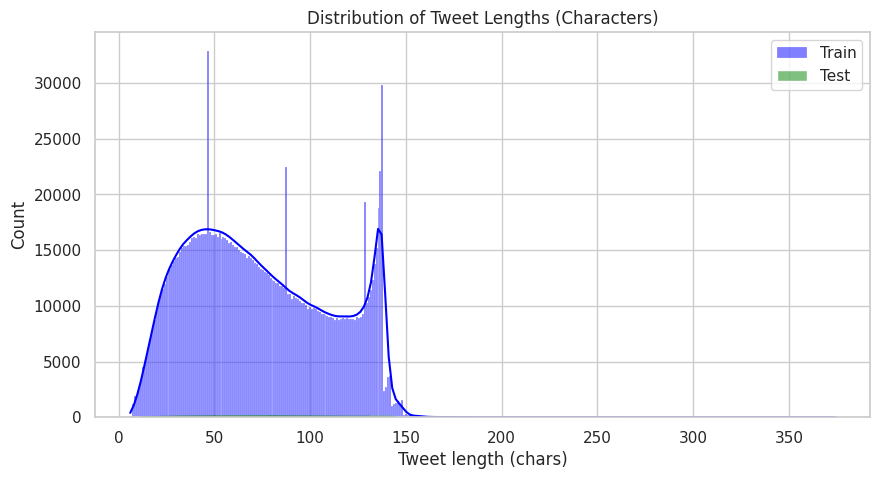

In [6]:
# Create a 'tweet_length' column for both train and test
train_df['tweet_length'] = train_df['text'].apply(len)
test_df['tweet_length']  = test_df['text'].apply(len)

# Basic statistics about tweet length
print("Training Tweet Length Stats:")
display(train_df['tweet_length'].describe())

print("\nTest Tweet Length Stats:")
display(test_df['tweet_length'].describe())

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(train_df['tweet_length'], color='blue', kde=True, label='Train')
sns.histplot(test_df['tweet_length'], color='green', kde=True, label='Test')
plt.title("Distribution of Tweet Lengths (Characters)")
plt.xlabel("Tweet length (chars)")
plt.legend()
plt.show()


/tmp/ipykernel_673672/2658070485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='polarity', y='tweet_length', data=train_df, palette='Set2')


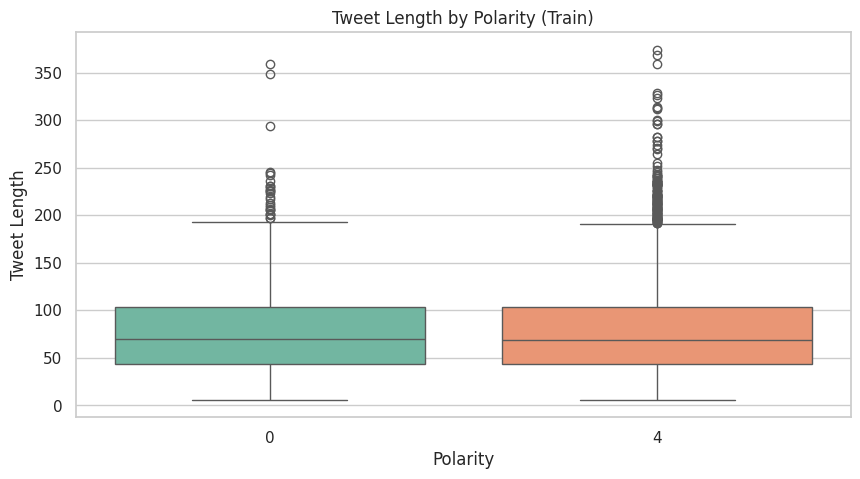

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(x='polarity', y='tweet_length', data=train_df, palette='Set2')
plt.title("Tweet Length by Polarity (Train)")
plt.xlabel("Polarity")
plt.ylabel("Tweet Length")
plt.show()


Number of unique users in Train: 659775
Number of unique users in Test: 490

Distribution of tweets per user (Train):


count    659775.000000
mean          2.425069
std           4.710913
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         549.000000
Name: count, dtype: float64

/tmp/ipykernel_673672/1091202595.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_users.values, y=top_10_users.index, palette='magma')


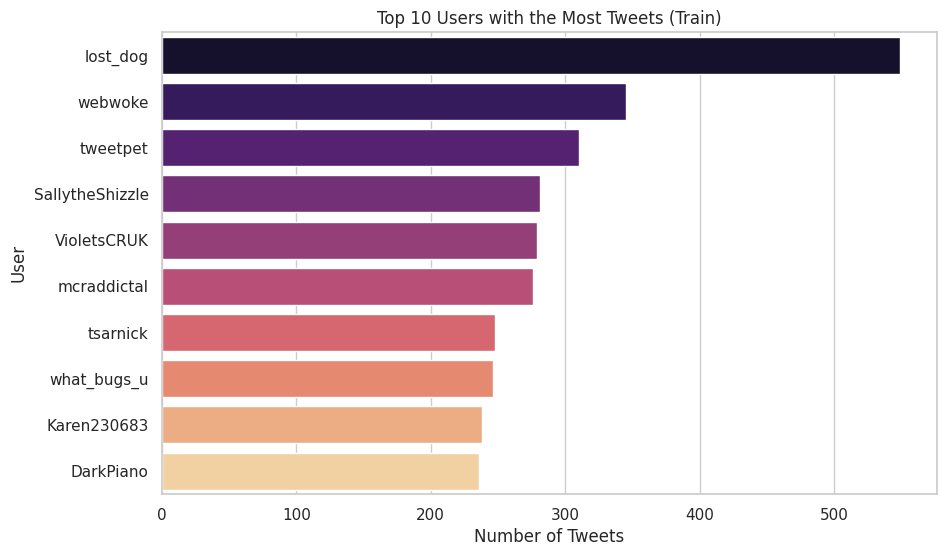

In [8]:
# Unique users in train
unique_train_users = train_df['user'].nunique()
print("Number of unique users in Train:", unique_train_users)

# Unique users in test
unique_test_users = test_df['user'].nunique()
print("Number of unique users in Test:", unique_test_users)

# Let's see how many tweets each user has in the training set
user_tweet_counts = train_df['user'].value_counts()
print("\nDistribution of tweets per user (Train):")
display(user_tweet_counts.describe())

# Plot top 10 users with most tweets (Train)
top_10_users = user_tweet_counts.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_10_users.values, y=top_10_users.index, palette='magma')
plt.title("Top 10 Users with the Most Tweets (Train)")
plt.xlabel("Number of Tweets")
plt.ylabel("User")
plt.show()



Distribution of tweets per user (Test):


count    490.000000
mean       1.016327
std        0.142066
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: count, dtype: float64

/tmp/ipykernel_673672/3638066192.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_test_users.values,


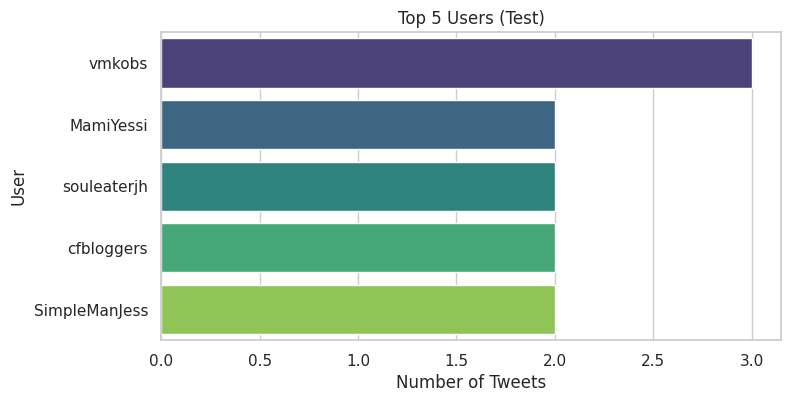

In [9]:
user_tweet_counts_test = test_df['user'].value_counts()
print("\nDistribution of tweets per user (Test):")
display(user_tweet_counts_test.describe())

top_5_test_users = user_tweet_counts_test.head(5)
plt.figure(figsize=(8,4))
sns.barplot(x=top_5_test_users.values, 
            y=top_5_test_users.index, 
            palette='viridis')
plt.title("Top 5 Users (Test)")
plt.xlabel("Number of Tweets")
plt.ylabel("User")
plt.show()


Total tokens (train): 21974007
Most common 20 words (Train):
i: 960288
to: 566077
the: 525386
a: 385618
my: 317022
it: 305502
and: 303735
you: 302390
is: 238648
in: 217079
for: 216451
s: 192873
t: 185904
of: 184107
on: 168525
me: 166439
that: 166144
so: 154299
have: 145647
m: 140837


/tmp/ipykernel_673672/2588595267.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='coolwarm')


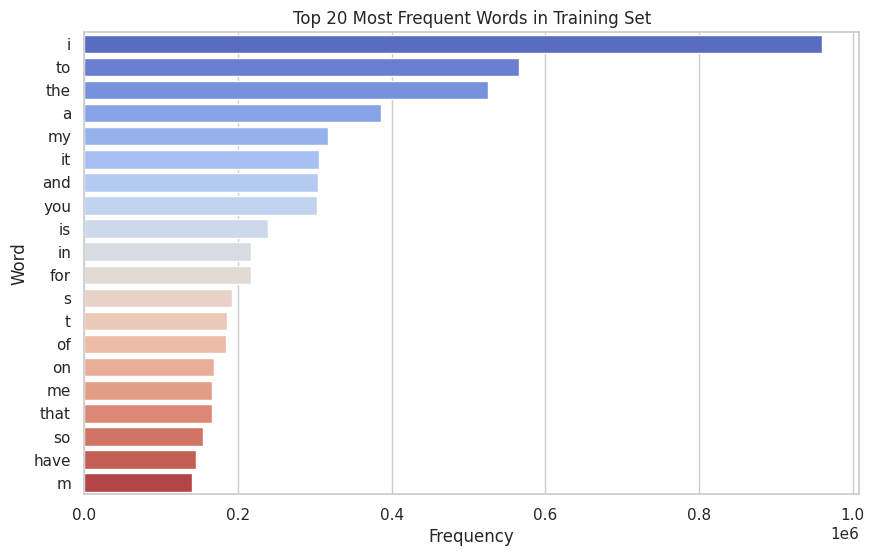

In [10]:
import re
from collections import Counter

def simple_tokenize(text):
    # Lowercase, split on non-alphabetic
    tokens = re.findall(r'[a-zA-Z]+', text.lower())
    return tokens

# Combine training tweets into one big list of tokens
all_train_tokens = []
for tweet in train_df['text']:
    all_train_tokens.extend(simple_tokenize(tweet))

print(f"Total tokens (train): {len(all_train_tokens)}")

# Count the top 20
counter = Counter(all_train_tokens)
most_common_20 = counter.most_common(20)
print("Most common 20 words (Train):")
for word, freq in most_common_20:
    print(f"{word}: {freq}")

# Quick bar plot
words, freqs = zip(*most_common_20)
plt.figure(figsize=(10,6))
sns.barplot(x=list(freqs), y=list(words), palette='coolwarm')
plt.title("Top 20 Most Frequent Words in Training Set")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()


/tmp/ipykernel_673672/1848264840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='polarity', y='word_count', data=train_df, palette='Set1')


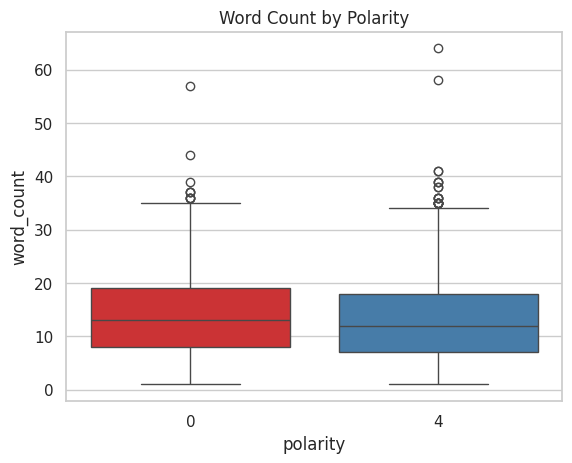

In [11]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
sns.boxplot(x='polarity', y='word_count', data=train_df, palette='Set1')
plt.title("Word Count by Polarity")
plt.show()


In [12]:
train_df['parsed_date'] = pd.to_datetime(train_df['date'], errors='coerce')
print(train_df['parsed_date'].head())


0   2009-04-06 22:19:45
1   2009-04-06 22:19:49
2   2009-04-06 22:19:53
3   2009-04-06 22:19:57
4   2009-04-06 22:19:57
Name: parsed_date, dtype: datetime64[ns]


/tmp/ipykernel_673672/3701675649.py:1: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  train_df['parsed_date'] = pd.to_datetime(train_df['date'], errors='coerce')


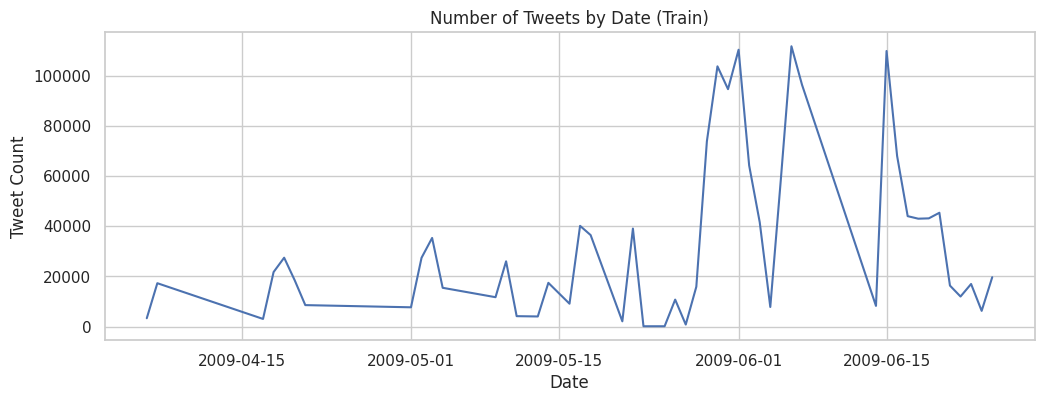

In [13]:
date_counts = train_df.groupby(train_df['parsed_date'].dt.date)['polarity'].count()
plt.figure(figsize=(12, 4))
date_counts.plot()
plt.title("Number of Tweets by Date (Train)")
plt.xlabel("Date")
plt.ylabel("Tweet Count")
plt.show()


In [14]:
train_df['text_length'] = train_df['text'].apply(len)
test_df['text_length']  = test_df['text'].apply(len)


In [15]:
# Boolean mask for tweets > 140 chars
train_mask = train_df['text_length'] > 140

# Count
num_long_train = train_mask.sum()
print("Number of training tweets > 140 chars:", num_long_train)

# Percentage
pct_long_train = (num_long_train / len(train_df)) * 100
print(f"Percentage of training tweets > 140 chars: {pct_long_train:.3f}%")


Number of training tweets > 140 chars: 17174
Percentage of training tweets > 140 chars: 1.073%


In [16]:
test_mask = test_df['text_length'] > 140

num_long_test = test_mask.sum()
print("Number of test tweets > 140 chars:", num_long_test)

pct_long_test = (num_long_test / len(test_df)) * 100
print(f"Percentage of test tweets > 140 chars: {pct_long_test:.3f}%")


Number of test tweets > 140 chars: 6
Percentage of test tweets > 140 chars: 1.205%


In [17]:
# Training examples
if num_long_train > 0:
    display(train_df[train_mask].head(5))
else:
    print("No training tweets exceed 140 characters.")

# Test examples
if num_long_test > 0:
    display(test_df[test_mask].head(5))
else:
    print("No test tweets exceed 140 characters.")


,polarity,id,date,query,user,text,tweet_length,word_count,parsed_date,text_length
213,0,1467863684,Mon Apr 06 22:33:35 PDT 2009,NO_QUERY,DjGundam,Awwh babs... you look so sad underneith that s...,142,23,2009-04-06 22:33:35,142
226,0,1467871844,Mon Apr 06 22:35:44 PDT 2009,NO_QUERY,larsgunnarf,Tuesdayï¿½ll start with reflection ï¿½n then a...,141,21,2009-04-06 22:35:44,141
279,0,1467881373,Mon Apr 06 22:38:18 PDT 2009,NO_QUERY,ForzaRagazza,Whinging. My client&amp;boss don't understand ...,145,18,2009-04-06 22:38:18,145
343,0,1467898061,Mon Apr 06 22:42:49 PDT 2009,NO_QUERY,Kevin_Lately,@TheLeagueSF Not Fun &amp; Furious? The new ma...,145,23,2009-04-06 22:42:49,145
400,0,1467913111,Mon Apr 06 22:46:57 PDT 2009,NO_QUERY,nssmom,#3 woke up and was having an accident - &quot;...,144,24,2009-04-06 22:46:57,144


,polarity,id,date,query,user,text,tweet_length,text_length
208,4,569,Sun Jun 07 21:38:16 UTC 2009,kindle2,rachaelbender,@BlondeBroad it's definitely under warranty &a...,143,143
209,2,570,Sun Jun 07 21:38:42 UTC 2009,kindle2,aqrinc,"RT Look, Available !Amazon Kindle2 &amp; Kindl...",144,144
213,0,574,Sun Jun 07 21:47:42 UTC 2009,time warner,MichelleEReagan,OMG - time warner f'ed up my internet install ...,142,142
227,0,598,Mon Jun 08 20:01:11 UTC 2009,at&t,brkd,pissed about at&amp;t's mid-contract upgrade p...,141,141
230,0,601,Mon Jun 08 20:06:57 UTC 2009,at&t,matthewphewes,@springsingfiend @dvyers @sethdaggett @jlshack...,144,144


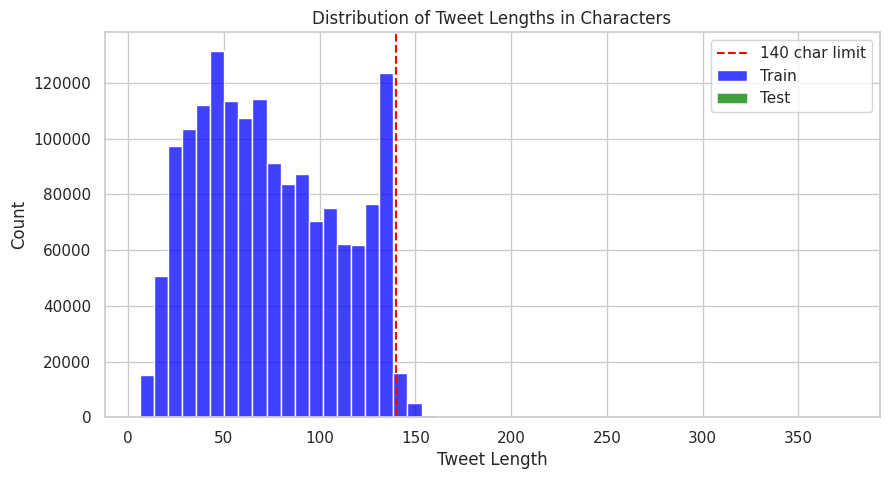

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

plt.figure(figsize=(10,5))
sns.histplot(train_df['text_length'], color='blue', kde=False, label='Train', bins=50)
sns.histplot(test_df['text_length'], color='green', kde=False, label='Test', bins=50)
plt.axvline(x=140, color='red', linestyle='--', label='140 char limit')
plt.title("Distribution of Tweet Lengths in Characters")
plt.xlabel("Tweet Length")
plt.ylabel("Count")
plt.legend()
plt.show()
